 # Crop Yield Forecasting - Model Data Set

Imaara K.
14/04/25 Training a machine learning model to predict crop yield using rainfall, temperature, and fertilizer inputs. The dataset is synthetic but is meant to mimic realistic agricultural patterns for model development and testing.

In [7]:
import pandas as pd

# Load the CSV
df = pd.read_csv("model_crop_data.csv")

# Display the first few rows
df.head()

,year,rainfall,temperature,fertilizer,yield
0,2000,117.5,15.5,93.8,6.36
1,2001,107.9,16.1,92.0,6.77
2,2002,119.7,13.2,80.2,6.53
3,2003,132.8,14.9,87.8,6.76
4,2004,106.5,16.2,90.4,6.76


# Step 1: Visualise Pairwise Relationships

              year    rainfall  temperature  fertilizer      yield
count    21.000000   21.000000    21.000000   21.000000  21.000000
mean   2010.000000  108.595238    15.438095   93.457143   6.551905
std       6.204837   15.022898     1.781425    8.138217   0.454617
min    2000.000000   81.300000    12.100000   77.400000   5.460000
25%    2005.000000  101.600000    13.900000   88.200000   6.380000
50%    2010.000000  106.500000    15.500000   92.000000   6.630000
75%    2015.000000  118.100000    16.400000   98.400000   6.770000
max    2020.000000  133.700000    19.700000  105.600000   7.150000


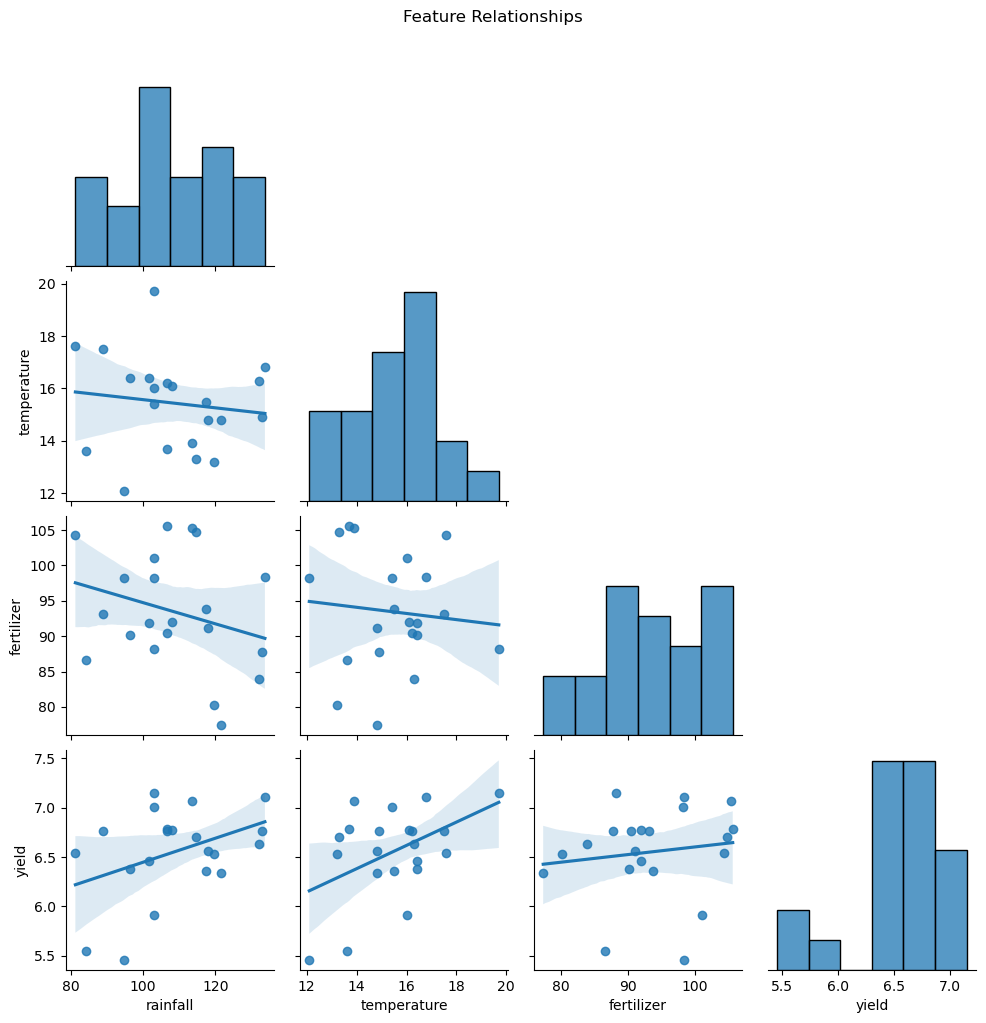

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print(df.describe())

# Pairplot of features vs yield
sns.pairplot(df[['rainfall', 'temperature', 'fertilizer', 'yield']], kind="reg", corner=True)
plt.suptitle("Feature Relationships", y=1.02)
plt.show()

# Step 2: Define Features/Target to Train and Test

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['rainfall', 'temperature', 'fertilizer']]
y = df['yield']

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Confirm the sizes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 5


# Step 3: Train Model 'Random Forest Regressor'

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Complete training
print("Model training complete")

Model training complete


# Step 4: Use Model to Make Predictions and Evaluate then Visualise

Mean Squared Error (MSE): 0.136
R² Score: -1.562


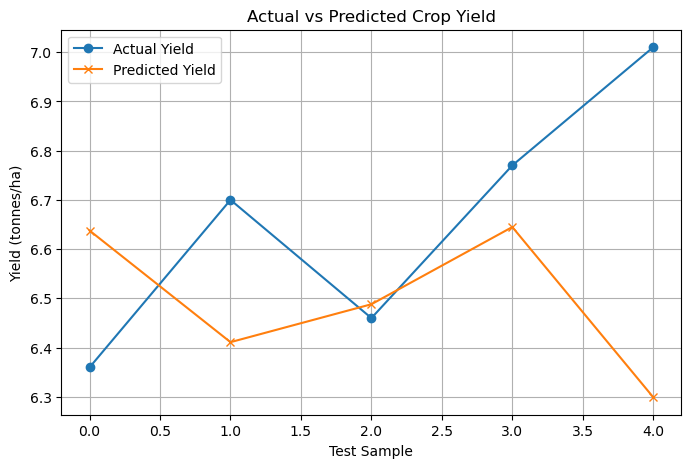

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Make predictions
preds = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R² Score: {r2:.3f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test.values, label="Actual Yield", marker='o')
plt.plot(preds, label="Predicted Yield", marker='x')
plt.title("Actual vs Predicted Crop Yield")
plt.xlabel("Test Sample")
plt.ylabel("Yield (tonnes/ha)")
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Find and Plot Feature Importance

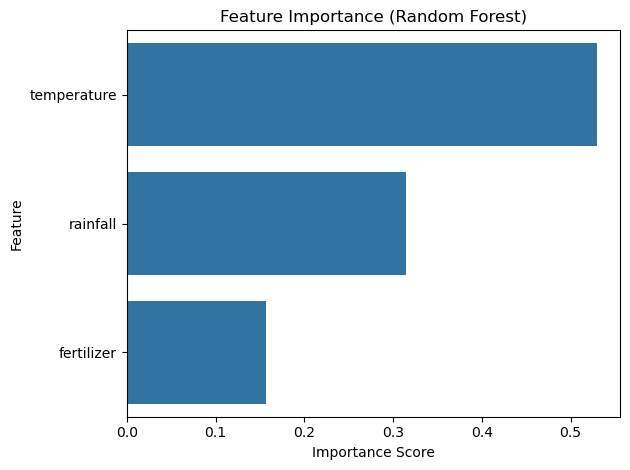

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get importance scores from trained Random Forest
importances = model.feature_importances_

# Match with feature names
feature_names = X.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()